In [16]:
import os, sys
sys.path.append(os.path.abspath('../..'))
from utlis.sync_utlis.general_loader import load_flat_with_frame_map, merge_pred_with_miniscope
from utlis.sync_utlis.general_loader_viz import plot_two_coms_from_pred_df


oct3v1 = "/data/big_rim/rsync_dcc_sum/Oct3V1"
rec_path = os.path.join(oct3v1, "2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30")
nc_key='wnd1500_stp700_max25_diff3.5_pnr1.1'
dannce_folder='SDANNCE/predict00'


merged = merge_pred_with_miniscope(
    rec_path=rec_path,
    nc_key=nc_key,
    dannce_folder=dannce_folder,
    com_folder=None,
    save_h5=False,
    save_csv=False,
)

merged.shape, merged.index[:3]

((12700, 273), Index([-5, 35, 64], dtype='int64', name='timestamp_ms_mini'))

In [17]:
merged

,com1_x,com2_x,com1_y,com2_y,com1_z,com2_z,kp1_x_a1,kp2_x_a1,kp3_x_a1,kp4_x_a1,...,dF_F_roi57,dF_F_roi58,dF_F_roi59,dF_F_roi60,dF_F_roi61,dF_F_roi62,dF_F_roi63,dF_F_roi64,dF_F_roi65,dF_F_roi66
timestamp_ms_mini,,,,,,,,,,,,,,,,,,,,,
-5,-412.380270,-372.665627,168.820058,200.239392,5.079139,7.018563,-431.659027,-402.266022,-407.163361,-415.559296,...,3.846425,0.160360,0.562013,1.219446,0.472723,3.115023,-0.437258,1.074143,1.836242,0.955372
35,-412.167869,-372.665627,168.820058,200.239392,5.129800,6.895860,-431.641388,-402.121399,-406.700989,-415.339935,...,1.990164,-0.033099,-0.115837,1.234995,0.543411,2.064591,-0.189175,0.230015,1.177422,0.444863
64,-412.167869,-372.661515,168.739270,200.244981,5.138774,6.874564,-431.271637,-401.848358,-406.995605,-415.006165,...,4.097898,0.719831,0.367163,0.944083,-0.004118,0.990298,0.014520,0.274250,1.095218,1.000371
97,-412.167869,-372.567755,168.112491,200.263531,5.164036,6.874564,-430.337097,-401.019714,-408.643646,-414.297760,...,5.739076,0.137995,0.453165,1.470531,-0.067698,3.152845,-0.119627,0.743295,1.994643,1.271365
130,-412.167869,-372.346276,168.062731,200.263531,5.168815,6.865812,-430.316772,-400.528381,-411.645172,-414.481903,...,5.367900,0.985956,0.681797,1.289066,0.164544,1.169032,-0.008408,0.377280,2.086859,1.212272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426643,-74.527784,-369.190341,297.357226,324.684113,10.250276,2.164954,-57.335758,-87.638435,-62.119793,-72.914978,...,2.425390,0.964610,0.650659,2.696483,1.803019,1.019831,1.167715,5.193545,1.598065,0.464752
426677,-74.527784,-369.190341,293.014935,324.684113,10.250276,2.101645,-54.560120,-86.277748,-61.356266,-71.028160,...,2.873516,1.069222,0.805097,1.827372,1.855294,1.831818,0.203849,3.870626,1.845874,0.768292
426710,-74.552294,-369.190341,288.680901,324.684113,10.250276,2.011307,-54.927963,-85.768623,-61.791847,-70.873260,...,3.649859,1.761857,0.467259,2.632054,1.443316,0.034877,0.089873,3.887457,0.850201,0.284287


In [18]:
json_path = "/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/MIR_Aligned/frame_mapping.json"

import json
from pathlib import Path

def lookup_sixcam_frame(mapping_json_path, target_timestamp, *, nearest=True):
    """
    Returns (sixcam_frame, idx, hit_type) where:
      - sixcam_frame is mapped_sixcam_frame_indices[idx]
      - idx is the position in the arrays
      - hit_type in {"exact","nearest"} tells whether we matched exactly or picked nearest
    Raises ValueError if arrays missing/mismatched or empty.
    """
    mapping_json_path = Path(mapping_json_path)
    with mapping_json_path.open("r") as f:
        m = json.load(f)

    ts = m.get("mini_cam_timestamps")
    fr = m.get("mapped_sixcam_frame_indices")
    if not isinstance(ts, list) or not isinstance(fr, list) or len(ts) != len(fr) or len(ts) == 0:
        raise ValueError("Bad mapping JSON: need equal-length non-empty lists 'mini_cam_timestamps' and 'mapped_sixcam_frame_indices'.")

    # Try exact hit first
    try:
        i = ts.index(target_timestamp)
        return fr[i], i, "exact"
    except ValueError:
        pass

    if not nearest:
        raise KeyError(f"{target_timestamp} not found in mini_cam_timestamps and nearest=False.")

    # Nearest match (absolute-time closest; tie → smaller index)
    # If timestamps are sorted, this is fine; if not, still works (linear scan).
    best_i, best_diff = None, None
    for i, t in enumerate(ts):
        d = abs(t - target_timestamp)
        if best_diff is None or d < best_diff or (d == best_diff and i < best_i):
            best_i, best_diff = i, d

    return fr[best_i], best_i, "nearest"

# ==== use it ====
mapping_path = json_path   # <-- put your real path here
target = 616837 #37764

sixcam_frame, idx, hit_type = lookup_sixcam_frame(mapping_path, target)
print(f"mini_cam_timestamps[{idx}] ~ {target} ({hit_type}) → sixcam frame = {sixcam_frame}")


mini_cam_timestamps[13436] ~ 616837 (nearest) → sixcam frame = 13742


In [19]:
from typing import Optional
import numpy as np
import pandas as pd

def distance3d(x1, y1, z1, x2, y2, z2):
    x1, y1, z1, x2, y2, z2 = map(np.asarray, (x1, y1, z1, x2, y2, z2))
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

def compute_com_distance(
    df: pd.DataFrame,
    p1: str = "com1",
    p2: str = "com2",
    smooth_window: Optional[int] = None,
    dist_smooth_window: Optional[int] = None,
    return_components: bool = False,   # <-- added
):
    cols = [f"{p1}_x", f"{p1}_y", f"{p1}_z", f"{p2}_x", f"{p2}_y", f"{p2}_z"]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # optional smoothing on positions first
    pos = (df[cols].rolling(int(smooth_window), center=True, min_periods=1).mean()
           if smooth_window and smooth_window > 1 else df[cols])

    x1, y1, z1 = pos[f"{p1}_x"], pos[f"{p1}_y"], pos[f"{p1}_z"]
    x2, y2, z2 = pos[f"{p2}_x"], pos[f"{p2}_y"], pos[f"{p2}_z"]

    dx = (x2 - x1).to_numpy()
    dy = (y2 - y1).to_numpy()
    dz = (z2 - z1).to_numpy()
    d  = distance3d(x1, y1, z1, x2, y2, z2)

    if return_components:
        out = pd.DataFrame(
            {"dx": dx, "dy": dy, "dz": dz, "dist_mm": d},
            index=df.index
        )
        if dist_smooth_window and dist_smooth_window > 1:
            out["dist_mm"] = out["dist_mm"].rolling(
                int(dist_smooth_window), center=True, min_periods=1
            ).mean()
        return out

    dist_s = pd.Series(d, index=df.index, name="dist_mm")
    if dist_smooth_window and dist_smooth_window > 1:
        dist_s = dist_s.rolling(int(dist_smooth_window), center=True, min_periods=1).mean()
    return dist_s


In [20]:
KP = {
    'EarL':1,'EarR':2,'Snout':3,'SpineF':4,'SpineM':5,
    'Tail(base)':6,'Tail(mid)':7,'Tail(end)':8,
    'ForepawL':9,'WristL':10,'ElbowL':11,'ShoulderL':12,
    'ForepawR':13,'WristR':14,'ElbowR':15,'ShoulderR':16,
    'HindpawL':17,'AnkleL':18,'KneeL':19,'HindpawR':20,'AnkleR':21,'KneeR':22
}

In [21]:
def _kp_idx(k):
    return KP[k] if isinstance(k, str) else int(k)


# --- 1) CoM proximity rows (uses your existing compute_com_distance) ---
def get_proximity_rows_by_com(df, threshold_mm=260.0, p1="com1", p2="com2", **kwargs):
    """
    Return df.index where CoM distance <= threshold_mm.
    kwargs are passed to compute_com_distance (e.g., smooth_window=3).
    """
    d = compute_com_distance(df, p1=p1, p2=p2, **kwargs)  # already in mm
    return d.index[d <= float(threshold_mm)]

# --- 2) Distance between ANY two tracked points (across animals) ---
def point_distance(df, kp_a1, kp_a2, a1="a1", a2="a2"):
    """
    Euclidean distance (mm) between kp_a1 of a1 and kp_a2 of a2.
    kp_* can be name ('Snout') or index (3).
    Expects columns like: kp3_x_a1, kp3_y_a1, kp3_z_a1, kp3_x_a2, ...
    Works for 2D or 3D depending on what columns exist.
    """
    i1 = _kp_idx(kp_a1)
    i2 = _kp_idx(kp_a2)

    # auto-detect axes present
    axes = [ax for ax in ("x","y","z")
            if f"kp{i1}_{ax}_{a1}" in df.columns and f"kp{i2}_{ax}_{a2}" in df.columns]
    if not axes:
        raise ValueError("No matching kp columns found (check names/animals).")

    # simple sqrt of squared diffs
    s = 0.0
    for ax in axes:
        a = df[f"kp{i1}_{ax}_{a1}"]
        b = df[f"kp{i2}_{ax}_{a2}"]
        s = s + (b - a)**2
    return (s**0.5).rename(f"kp{i1}_{a1}__to__kp{i2}_{a2}_mm")

# --- 3) Snout-to-<whatever> convenience (optionally on proximity rows) ---
def snout_to(df, others=("Snout","Tail(base)", 'SpineM'), rows=None, a1="a1", a2="a2"):
    """
    Return a DataFrame of snout(a1) to each item in `others` on selected rows.
    """
    idx = df.index if rows is None else rows
    out = {}
    for o in others:
        dist = point_distance(df.loc[idx], "Snout", o, a1=a1, a2=a2)
        # short label
        o_lab = (o if isinstance(o,str) else f"kp{int(o)}").replace("(", "").replace(")", "").replace(" ", "").lower()
        out[f"snout_{a1}__to__{o_lab}_{a2}_mm"] = dist
    return pd.DataFrame(out, index=idx)

In [22]:
df = merged

rows = get_proximity_rows_by_com(df, threshold_mm=260.0, p1="com1", p2="com2", smooth_window=1)
snout_pairs = snout_to(df, others=("Snout","Tail(base)",'SpineM'), rows=rows, a1="a1", a2="a2")
# if you want a single pair explicitly:
snout_to_tailbase = point_distance(df.loc[rows], "Snout", "Tail(base)", a1="a1", a2="a2")


In [23]:
rows

Index([    -5,     35,     64,     97,    130,    165,    198,    233,    267,
          299,
       ...
       383289, 383321, 383353, 383388, 383420, 383454, 383487, 383521, 383555,
       383589],
      dtype='int64', name='timestamp_ms_mini', length=2597)

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# zero-based skeleton edges (your list)
MOUSE22_EDGES = [
    (0,1),(1,2),(0,2),
    (0,3),(1,3),(2,3),
    (3,4),(4,5),(5,6),(6,7),
    (8,9),(9,10),(10,11),(11,3),
    (12,13),(13,14),(14,15),(15,3),
    (16,17),(17,18),(18,4),
    (19,20),(20,21),(21,4),
]

# simple name→index (1-based) for convenience
KP = {
    'EarL':1,'EarR':2,'Snout':3,'SpineF':4,'SpineM':5,
    'Tail(base)':6,'Tail(mid)':7,'Tail(end)':8,
    'ForepawL':9,'WristL':10,'ElbowL':11,'ShoulderL':12,
    'ForepawR':13,'WristR':14,'ElbowR':15,'ShoulderR':16,
    'HindpawL':17,'AnkleL':18,'KneeL':19,'HindpawR':20,'AnkleR':21,'KneeR':22
}

def _kp_xy_row(df, idx, animal="a1"):
    """
    Return (22,2) array for x,y at a single frame index.
    Row i (0-based) corresponds to kp{i+1}.
    """
    r = df.loc[idx]
    xy = np.empty((22, 2), dtype=float)
    for k in range(1, 23):  # 1..22
        xy[k-1, 0] = r.get(f"kp{k}_x_{animal}", np.nan)
        xy[k-1, 1] = r.get(f"kp{k}_y_{animal}", np.nan)
    return xy

def _pair_dist(a_xy, b_xy, i_a, i_b):
    """
    Euclidean distance between point i_a (0-based) of a_xy and i_b of b_xy.
    """
    dx = b_xy[i_b,0] - a_xy[i_a,0]
    dy = b_xy[i_b,1] - a_xy[i_a,1]
    return float((dx*dx + dy*dy) ** 0.5)

def _time_label(idx_name, idx_value):
    if idx_name and ("ms" in str(idx_name).lower()):
        return f"{idx_value/1000.0:.3f}s"
    return f"frame {int(idx_value)}"

def plot_skeleton_frames(
    df,
    rows,
    n=10,
    animal1="a1",
    animal2="a2",
    pairs=(("Snout","Snout"), ("Snout","Tail(base)"), ("Snout","Tail(end)")),
    threshold_mm=None,      # if given, pair lines under threshold are highlighted thicker
    invert_y=False          # set True if your y-axis is image-style
):
    idx_sel = list(rows)[:int(n)]
    if not idx_sel:
        raise ValueError("No rows to plot.")

    # precompute global xy limits (both animals, selected frames)
    xs, ys = [], []
    for idx in idx_sel:
        a1 = _kp_xy_row(df, idx, animal=animal1)
        a2 = _kp_xy_row(df, idx, animal=animal2)
        xs.extend([a1[:,0].min(), a1[:,0].max(), a2[:,0].min(), a2[:,0].max()])
        ys.extend([a1[:,1].min(), a1[:,1].max(), a2[:,1].min(), a2[:,1].max()])
    xmin, xmax = np.nanmin(xs), np.nanmax(xs)
    ymin, ymax = np.nanmin(ys), np.nanmax(ys)
    pad_x = 0.05 * max(1.0, xmax - xmin)
    pad_y = 0.05 * max(1.0, ymax - ymin)

    # grid
    cols = min(5, max(1, len(idx_sel)))
    rows_grid = int(np.ceil(len(idx_sel) / cols))
    fig, axes = plt.subplots(rows_grid, cols, figsize=(4*cols, 4*rows_grid), squeeze=False)

    # prepare pair indices (0-based)
    def _to_kp0(x):
        return (KP[x]-1) if isinstance(x, str) else (int(x)-1)

    pair_idx = [(_to_kp0(a), _to_kp0(b)) for (a,b) in pairs]

    # draw
    for k, idx in enumerate(idx_sel):
        r = k // cols
        c = k % cols
        ax = axes[r][c]
        a1 = _kp_xy_row(df, idx, animal=animal1)
        a2 = _kp_xy_row(df, idx, animal=animal2)

        # skeleton lines
        for i, j in MOUSE22_EDGES:
            if not (np.any(np.isnan(a1[[i,j]])) or np.any(np.isnan(a2[[i,j]]))):
                ax.plot([a1[i,0], a1[j,0]], [a1[i,1], a1[j,1]], linewidth=1)      # animal1
                ax.plot([a2[i,0], a2[j,0]], [a2[i,1], a2[j,1]], linewidth=1)      # animal2

        # keypoints (small)
        ax.scatter(a1[:,0], a1[:,1], s=8)
        ax.scatter(a2[:,0], a2[:,1], s=8)

        # COM if present
        if f"com1_x" in df.columns and f"com1_y" in df.columns:
            ax.scatter(df.loc[idx, "com1_x"], df.loc[idx, "com1_y"], s=30, marker='x')
        if f"com2_x" in df.columns and f"com2_y" in df.columns:
            ax.scatter(df.loc[idx, "com2_x"], df.loc[idx, "com2_y"], s=30, marker='x')

        # pair lines (across animals)
        title_bits = []
        for ia, ib in pair_idx:
            if (not np.any(np.isnan(a1[ia])) and not np.any(np.isnan(a2[ib]))):
                d = _pair_dist(a1, a2, ia, ib)
                lw = 2.5 if (threshold_mm is not None and d <= float(threshold_mm)) else 1.0
                ax.plot([a1[ia,0], a2[ib,0]], [a1[ia,1], a2[ib,1]], linewidth=lw)
                title_bits.append(f"d{k}-{ia+1}->{ib+1}:{d:.1f}mm")
        # time/idx in title
        ax.set_title(_time_label(df.index.name, idx))

        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)
        if invert_y:
            ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])

    # hide any unused axes
    total = rows_grid * cols
    for k in range(len(idx_sel), total):
        r = k // cols
        c = k % cols
        axes[r][c].axis('off')

    plt.tight_layout()
    plt.show()


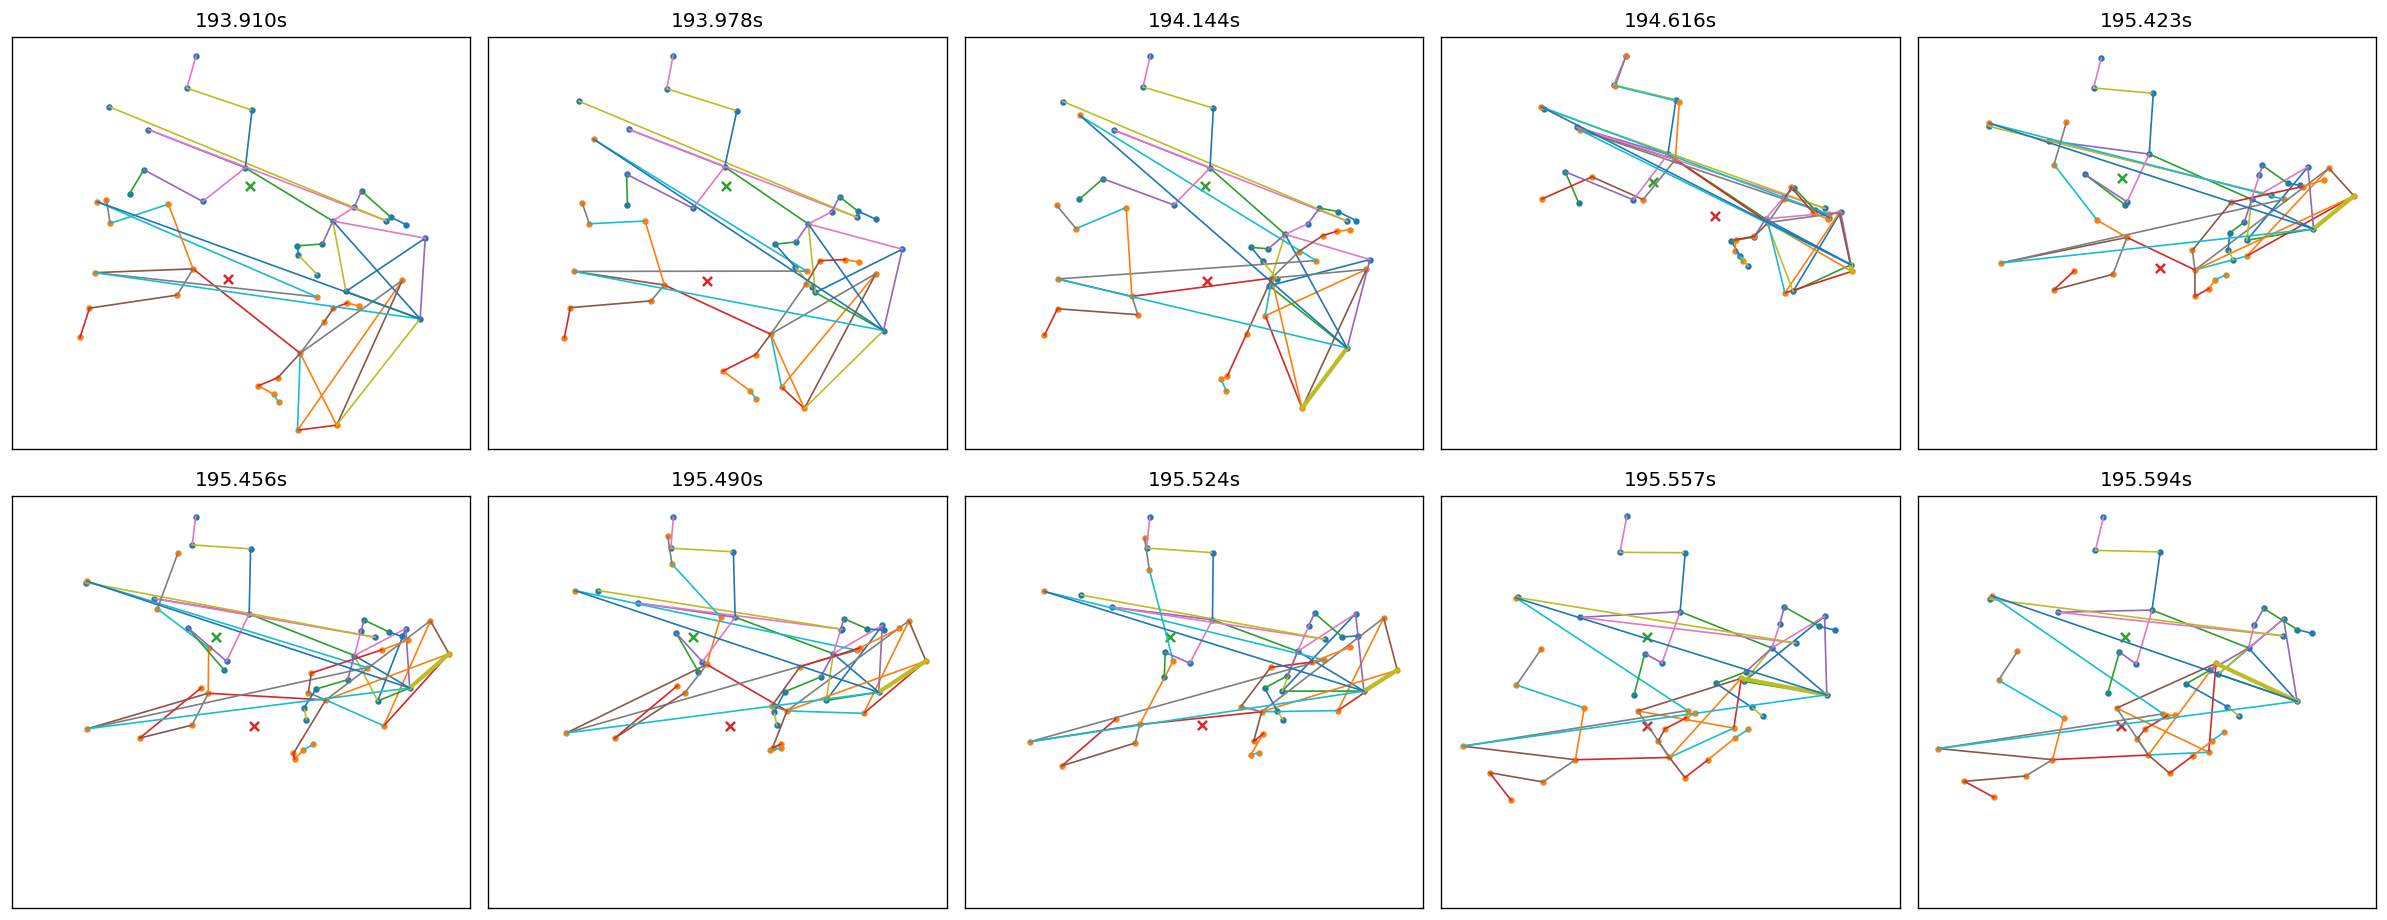

In [25]:
threshold_mm=30.0

# 1) pick proximity frames by CoM
rows = get_proximity_rows_by_com(df, threshold_mm=threshold_mm, p1="com1", p2="com2", smooth_window=1)

# 2) plot first 10 frames; draw snout↔snout, snout↔tail(base), snout↔tail(end)
plot_skeleton_frames(
    df,
    rows,
    n=10,
    animal1="a1",
    animal2="a2",
    pairs=(("Snout","Snout"), ("Snout","Tail(base)"), ("Snout","Tail(end)")),
    threshold_mm=threshold_mm,
    invert_y=False  # set True if your y is image coordinates
)


In [120]:
import numpy as np
import matplotlib.pyplot as plt

def _time_axis(idx):
    """use seconds if the index name contains 'ms', else frames"""
    t = np.asarray(idx, float)
    if getattr(idx, "name", None) and ("ms" in str(idx.name).lower()):
        return t / 1000.0, "time (s)"
    return t, "frame"

def plot_snout_pairs(snout_pairs, threshold_mm=260.0, mark_under=True):
    """
    One simple figure per column in `snout_pairs`.
    Draws a horizontal threshold line; optionally marks points under threshold.
    """
    t, xlabel = _time_axis(snout_pairs.index)
    for col in snout_pairs.columns:
        y = snout_pairs[col].to_numpy()
        plt.figure(figsize=(10, 3))
        plt.plot(t, y, linewidth=1)
        plt.axhline(float(threshold_mm), linestyle="--", linewidth=1)
        if mark_under:
            m = y <= float(threshold_mm)
            if m.any():
                plt.scatter(t[m], y[m], s=6)
        plt.title(col)
        plt.xlabel(xlabel)
        plt.ylabel("distance (mm)")
        plt.tight_layout()
        plt.show()

def snout_single_pair(snout_to_tailbase, threshold_mm=260.0, mark_under=True, title=None):
    """
    Simple single-series plot for your `snout_to_tailbase` Series.
    """
    t, xlabel = _time_axis(snout_to_tailbase.index)
    y = snout_to_tailbase.to_numpy()
    plt.figure(figsize=(10, 3))
    plt.plot(t, y, linewidth=1)
    plt.axhline(float(threshold_mm), linestyle="--", linewidth=1)
    if mark_under:
        m = y <= float(threshold_mm)
        if m.any():
            plt.scatter(t[m], y[m], s=6)
    plt.title(title if title else getattr(snout_to_tailbase, "name", "snout_to_tailbase_mm"))
    plt.xlabel(xlabel)
    plt.ylabel("distance (mm)")
    plt.tight_layout()
    plt.show()


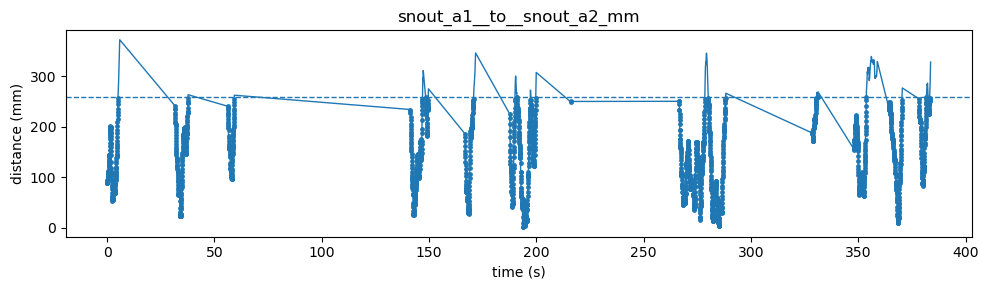

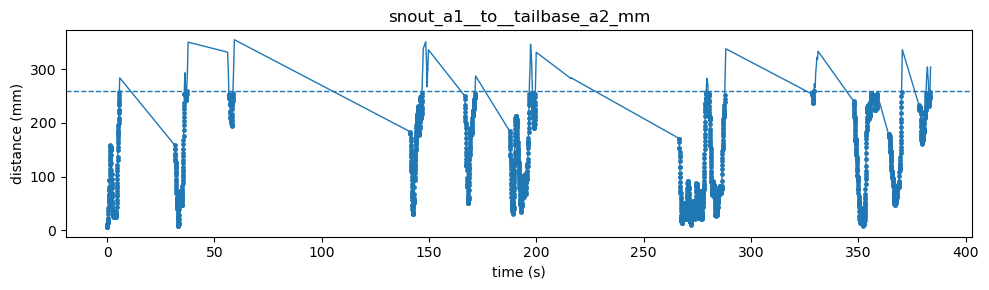

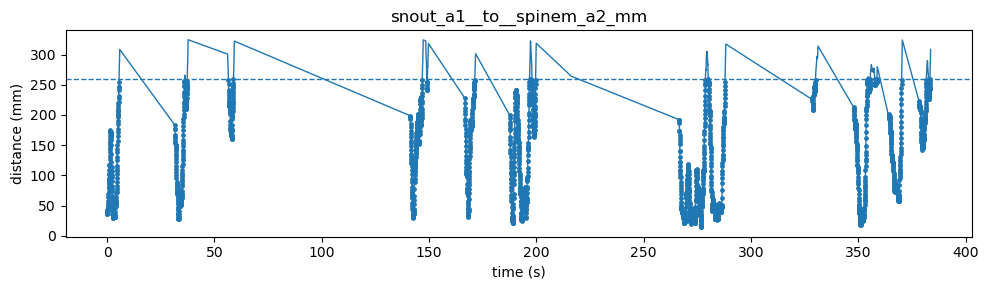

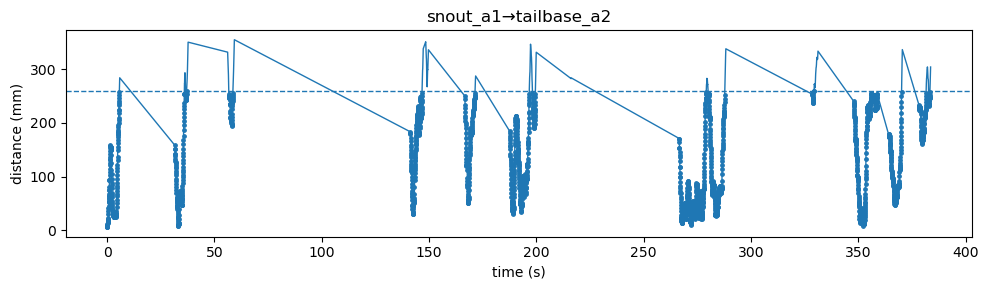

In [121]:

plot_snout_pairs(snout_pairs, threshold_mm=260.0)
snout_single_pair(snout_to_tailbase, threshold_mm=260.0, title="snout_a1→tailbase_a2")

In [122]:
# import numpy as np
# import pandas as pd

# # ---------- dummy data ----------
# def make_dummy_df():
#     """
#     5 frames, ms index. com2 moves toward com1 along +x → distances: 100, 80, 60, 40, 20 (mm).
#     Snout == CoM for both animals. Tail(base) of a2 is +50 mm in x from its CoM.
#     """
#     idx = pd.Index([0, 100, 200, 300, 400], name="timestamp_ms_mini")
#     df = pd.DataFrame(index=idx)

#     # CoMs
#     df["com1_x"] = 0.0; df["com1_y"] = 0.0; df["com1_z"] = 0.0
#     x2 = np.array([100, 80, 60, 40, 20], float)  # approaching
#     df["com2_x"] = x2;  df["com2_y"] = 0.0;     df["com2_z"] = 0.0

#     # kp3 (Snout) == CoM for simplicity
#     for ax in ("x","y","z"):
#         df[f"kp3_{ax}_a1"] = df[f"com1_{ax}"]
#         df[f"kp3_{ax}_a2"] = df[f"com2_{ax}"]

#     # kp6 (Tail(base)) for a2 at +50 mm in x
#     df["kp6_x_a2"] = df["com2_x"] + 50.0
#     df["kp6_y_a2"] = 0.0
#     df["kp6_z_a2"] = 0.0
#     return df

# # ---------- validation harness ----------
# def validate_dummy():
#     df = make_dummy_df()

#     # 1) CoM distance check (should be [100, 80, 60, 40, 20])
#     d = compute_com_distance(df, p1="com1", p2="com2", smooth_window=1)
#     assert np.allclose(d.values, [100,80,60,40,20]), f"CoM dist mismatch: {d.values}"

#     # 2) proximity rows under 60 mm → timestamps [200, 300, 400]
#     rows = get_proximity_rows_by_com(df, threshold_mm=60.0, p1="com1", p2="com2", smooth_window=1)
#     assert list(rows) == [200,300,400], f"rows mismatch: {list(rows)}"

#     # 3) point distances (simple sqrt of squared diffs)
#     sn_sn = point_distance(df.loc[rows], "Snout", "Snout", a1="a1", a2="a2")
#     assert np.allclose(sn_sn.values, [60,40,20]), f"snout↔snout mismatch: {sn_sn.values}"

#     sn_tail = point_distance(df.loc[rows], "Snout", "Tail(base)", a1="a1", a2="a2")
#     assert np.allclose(sn_tail.values, [110,90,70]), f"snout↔tail(base) mismatch: {sn_tail.values}"

#     # 4) convenience wrapper
#     tbl = snout_to(df, others=("Snout","Tail(base)"), rows=rows, a1="a1", a2="a2")
#     assert np.allclose(tbl["snout_a1__to__snout_a2_mm"].values, [60,40,20])
#     assert np.allclose(tbl["snout_a1__to__tailbase_a2_mm"].values, [110,90,70])

#     print("✓ dummy validation passed.")

# # run once:
# validate_dummy()


In [123]:
# snout_pairs

In [34]:
from typing import Optional, Union, Tuple, Dict, List
import numpy as np
import pandas as pd

# this works, but might have a bug? anyway made two fucntions this is just useless...
# def compute_com_distance(
#     df: pd.DataFrame,
#     p1: str = "com1",
#     p2: str = "com2",
#     smooth_window: int = 1,           # smooth positions before computing distance
#     dist_smooth_window: int = 1,      # optional second smoothing on the distance itself
#     return_components: bool = False   # if True, also returns dx,dy,dz
# ) -> Union[pd.Series, pd.DataFrame]:
#     """
#     Returns pairwise 3D distance (mm) between p1 and p2. If return_components=True,
#     returns a DataFrame with columns ['dx','dy','dz','dist_mm'].
#     """
#     def _need(cols):
#         miss = [c for c in cols if c not in df.columns]
#         if miss:
#             raise ValueError(f"Missing columns: {miss}")

#     _need([f"{p1}_x", f"{p1}_y", f"{p1}_z", f"{p2}_x", f"{p2}_y", f"{p2}_z"])

#     # Optional position smoothing (centered)
#     if smooth_window and smooth_window > 1:
#         pos = df[[f"{p1}_x", f"{p1}_y", f"{p1}_z", f"{p2}_x", f"{p2}_y", f"{p2}_z"]] \
#               .rolling(window=int(smooth_window), center=True, min_periods=1).mean()
#     else:
#         pos = df[[f"{p1}_x", f"{p1}_y", f"{p1}_z", f"{p2}_x", f"{p2}_y", f"{p2}_z"]].copy()

#     dx = pos[f"{p2}_x"].to_numpy() - pos[f"{p1}_x"].to_numpy()
#     dy = pos[f"{p2}_y"].to_numpy() - pos[f"{p1}_y"].to_numpy()
#     dz = pos[f"{p2}_z"].to_numpy() - pos[f"{p1}_z"].to_numpy()
#     dist = np.sqrt(dx*dx + dy*dy + dz*dz)

#     dist_s = pd.Series(dist, index=df.index, name="dist_mm")
#     if dist_smooth_window and dist_smooth_window > 1:
#         dist_s = dist_s.rolling(window=int(dist_smooth_window), center=True, min_periods=1).mean()

#     if return_components:
#         out = pd.DataFrame({"dx": dx, "dy": dy, "dz": dz, "dist_mm": dist}, index=df.index)
#         if dist_smooth_window and dist_smooth_window > 1:
#             out["dist_mm"] = dist_s
#         return out
#     else:
#         return dist_s


def _time_seconds(df: pd.DataFrame, time_col: Optional[str], fps: Optional[float]) -> Tuple[np.ndarray, str]:
    """
    Returns (t_sec, units_str). If time_col provided and name contains 'ms', converts to seconds.
    If no time_col and fps is given, builds t from frame index. Else uses frame units.
    """
    if time_col and (time_col in df.columns):
        t = df[time_col].to_numpy()
        if "ms" in time_col.lower():
            return t / 1000.0, "s"
        return t.astype(float), "s"
    if fps and fps > 0:
        n = len(df)
        return np.arange(n, dtype=float) / float(fps), "s"
    return np.arange(len(df), dtype=float), "frames"


def compute_motion_direction(
    df: pd.DataFrame,
    prefix: str = "com1",
    time_col: Optional[str] = "timestamp_ms_mini",
    fps: Optional[float] = None,
    pos_smooth: int = 1,
    vel_smooth: int = 1,
    fill_na: bool = False, #True,
    eps: float = 1e-9
) -> pd.DataFrame:
    """
    Computes velocity (vx,vy,vz), speed, and unit direction (ux,uy,uz).
    Units are mm/s if time axis is seconds; else mm/frame.
    """
    need = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns for '{prefix}': {miss}")

    pos = df[need].copy()
    if pos_smooth and pos_smooth > 1:
        pos = pos.rolling(window=int(pos_smooth), center=True, min_periods=1).mean()
    if fill_na:
        pos = pos.interpolate(method="linear", limit_direction="both")

    t_sec, t_units = _time_seconds(df, time_col, fps)

    vx = np.gradient(pos[f"{prefix}_x"].to_numpy(), t_sec)
    vy = np.gradient(pos[f"{prefix}_y"].to_numpy(), t_sec)
    vz = np.gradient(pos[f"{prefix}_z"].to_numpy(), t_sec)

    vel = pd.DataFrame({f"{prefix}_vx": vx, f"{prefix}_vy": vy, f"{prefix}_vz": vz}, index=df.index)
    if vel_smooth and vel_smooth > 1:
        vel = vel.rolling(window=int(vel_smooth), center=True, min_periods=1).mean()

    speed = np.sqrt(vel[f"{prefix}_vx"]**2 + vel[f"{prefix}_vy"]**2 + vel[f"{prefix}_vz"]**2)
    ux = vel[f"{prefix}_vx"] / (speed + eps)
    uy = vel[f"{prefix}_vy"] / (speed + eps)
    uz = vel[f"{prefix}_vz"] / (speed + eps)

    out = pd.concat([
        vel,
        pd.Series(speed, index=df.index, name=f"{prefix}_speed"),
        pd.Series(ux, index=df.index, name=f"{prefix}_ux"),
        pd.Series(uy, index=df.index, name=f"{prefix}_uy"),
        pd.Series(uz, index=df.index, name=f"{prefix}_uz"),
    ], axis=1)
    out.attrs["units"] = "mm/s" if t_units == "s" else "mm/frame"
    return out


def _boolean_runs(mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run-length encoding of a boolean mask.
    Returns (starts, ends) as index positions where mask is True. Interval is [start, end).
    """
    if mask.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    m = mask.astype(np.int8)
    edges = np.diff(np.pad(m, (1, 1), constant_values=0))
    starts = np.flatnonzero(edges == 1)
    ends   = np.flatnonzero(edges == -1)
    return starts, ends

def detect_approaches(
    df: pd.DataFrame,
    p1: str = "com1",
    p2: str = "com2",
    time_col: Optional[str] = "timestamp_ms_mini",
    fps: Optional[float] = None,
    pos_smooth: int = 3,
    vel_smooth: int = 3,
    radial_thresh: float = 20.0,
    speed_min: float = 5.0,
    dist_min: Optional[float] = None,
    dist_max: Optional[float] = None,
    min_samples: int = 5,
    return_intervals: bool = True,
    eps: float = 1e-9
) -> Dict[str, Union[pd.DataFrame, Dict[str, List[dict]]]]:

    # 1) Distances & relative vector
    comps = compute_com_distance(df, p1, p2, smooth_window=pos_smooth, return_components=True)
    dx, dy, dz = comps["dx"].to_numpy(), comps["dy"].to_numpy(), comps["dz"].to_numpy()
    dist = comps["dist_mm"].to_numpy()
    u12 = np.column_stack([dx, dy, dz])
    denom = np.maximum(dist, eps)[:, None]
    u12 = u12 / denom

    # 2) Velocities & speeds
    m1 = compute_motion_direction(df, prefix=p1, time_col=time_col, fps=fps,
                                  pos_smooth=pos_smooth, vel_smooth=vel_smooth)
    m2 = compute_motion_direction(df, prefix=p2, time_col=time_col, fps=fps,
                                  pos_smooth=pos_smooth, vel_smooth=vel_smooth)

    v1 = np.column_stack([m1[f"{p1}_vx"].to_numpy(),
                          m1[f"{p1}_vy"].to_numpy(),
                          m1[f"{p1}_vz"].to_numpy()])
    v2 = np.column_stack([m2[f"{p2}_vx"].to_numpy(),
                          m2[f"{p2}_vy"].to_numpy(),
                          m2[f"{p2}_vz"].to_numpy()])
    speed1 = m1[f"{p1}_speed"].to_numpy()
    speed2 = m2[f"{p2}_speed"].to_numpy()

    # 3) Radial-toward components
    radial1 = (v1 * u12).sum(axis=1)
    radial2 = (v2 * (-u12)).sum(axis=1)

    # 4) Distance rate dD/dt
    t_sec, t_units = _time_seconds(df, time_col, fps)
    dD_dt = np.gradient(dist, t_sec)

    # 5) Flags with optional distance gating
    in_band = np.ones_like(dist, dtype=bool)
    if dist_min is not None:
        in_band &= (dist >= float(dist_min))
    if dist_max is not None:
        in_band &= (dist <= float(dist_max))

    approach1 = (radial1 >= radial_thresh) & (speed1 >= speed_min) & in_band
    approach2 = (radial2 >= radial_thresh) & (speed2 >= speed_min) & in_band
    mutual    = approach1 & approach2

    # 6) Min-duration cleanup (frames-level)
    def _minlen_filter(mask: np.ndarray, k: int) -> np.ndarray:
        if k <= 1:
            return mask
        s, e = _boolean_runs(mask)
        keep = np.ones_like(mask, dtype=bool)
        for i in range(len(s)):
            if (e[i] - s[i]) < k:
                keep[s[i]:e[i]] = False
        return mask & keep

    if min_samples and min_samples > 1:
        approach1 = _minlen_filter(approach1, int(min_samples))
        approach2 = _minlen_filter(approach2, int(min_samples))
        mutual    = _minlen_filter(mutual,    int(min_samples))

    # 6.5) Pass-through alignment columns if present
    passthrough_cols = []
    for c in ("camera_frame_sixcam", "mapped_sixcam_frame_indices"):
        if c in df.columns:
            passthrough_cols.append(c)

    # 7) Assemble frames
    data = {
        "dist_mm": dist,
        "dD_dt": dD_dt,
        "radial1": radial1,
        "radial2": radial2,
        "speed1": speed1,
        "speed2": speed2,
        "approach1": approach1,
        "approach2": approach2,
        "mutual": mutual,
    }
    # attach passthroughs under original names
    for c in passthrough_cols:
        data[c] = df[c].to_numpy()

    frames = pd.DataFrame(data, index=df.index)
    frames.attrs["velocity_units"] = "mm/s" if t_units == "s" else "mm/frame"

    intervals: Dict[str, List[dict]] = {}
    if return_intervals:
        def _summarize(mask: np.ndarray, label: str) -> List[dict]:
            s, e = _boolean_runs(mask)
            if s.size == 0:
                return []
            out: List[dict] = []
            for i in range(len(s)):
                sl = slice(s[i], e[i])
                t0 = float(t_sec[s[i]])
                t1 = float(t_sec[e[i]-1])
                out.append({
                    "label": label,
                    "start_idx": int(s[i]),
                    "end_idx_exclusive": int(e[i]),
                    "start_time_s": t0 if t_units == "s" else None,
                    "end_time_s":   t1 if t_units == "s" else None,
                    "duration_s":   (t1 - t0) if t_units == "s" else None,
                    "min_dist_mm": float(np.nanmin(dist[sl])),
                    "median_dist_mm": float(np.nanmedian(dist[sl])),
                    "max_radial_mm_per_s": float(np.nanmax(radial1[sl] if label=="approach1" else radial2[sl])),
                    "median_speed_mm_per_s": float(np.nanmedian(speed1[sl] if label=="approach1" else speed2[sl])),
                })
            return out

        intervals = {
            "approach1": _summarize(approach1, "approach1"),
            "approach2": _summarize(approach2, "approach2"),
            "mutual":    _summarize(mutual,    "mutual"),
        }

    return {"frames": frames, "intervals": intervals}


In [125]:
# merged

In [35]:
# 0) If you want distance only
dist = compute_com_distance(merged, p1="com1", p2="com2", smooth_window=5)
print(dist.head())

# 1) Motion vectors / directions for each animal
m1 = compute_motion_direction(merged, prefix="com1", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)
m2 = compute_motion_direction(merged, prefix="com2", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)
print(m1.filter(like="_speed").head(), m2.filter(like="_speed").head())

# 2) Detect approach windows (tune thresholds as you like)
res = detect_approaches(
    merged,
    p1="com1", p2="com2",
    time_col="timestamp_ms_mini",   # if absent, pass fps=...
    pos_smooth=5, vel_smooth=5,
    radial_thresh=20.0,             # mm/s toward the other
    speed_min=5.0,                  # mm/s total speed floor
    dist_min=None,                  # e.g., set 50.0 to ignore near-collisions if needed
    dist_max=300.0,                 # focus on interaction zone
    min_samples=15,                 # ≥15 consecutive frames
    return_intervals=True
)

# Per-frame booleans + metrics
res["frames"][["dist_mm","radial1","radial2","approach1","approach2","mutual"]].head()

# Interval summaries (list of dicts)
res["intervals"]["approach1"][:3], res["intervals"]["approach2"][:3], res["intervals"]["mutual"][:3]


timestamp_ms_mini
-5      50.580713
 35     50.694257
 64     50.803232
 97     50.946379
 130    51.173287
Name: dist_mm, dtype: float64
                   com1_speed
timestamp_ms_mini            
-5                   0.154367
 35                  0.162126
 64                  0.167439
 97                  0.159762
 130                 0.147180                    com2_speed
timestamp_ms_mini            
-5                   0.047668
 35                  0.057717
 64                  0.065080
 97                  0.077614
 130                 0.081325


([], [], [])

In [147]:
res['frames']

,dist_mm,dD_dt,radial1,radial2,speed1,speed2,approach1,approach2,mutual,camera_frame_sixcam
timestamp_ms_mini,,,,,,,,,,
-5,50.580713,0.113544,-0.079223,-0.037451,0.154367,0.047668,False,False,False,202
35,50.694257,0.111260,-0.088469,-0.045433,0.162126,0.057717,False,False,False,203
64,50.803232,0.126061,-0.100860,-0.051929,0.167439,0.065080,False,False,False,204
97,50.946379,0.185027,-0.104587,-0.061919,0.159762,0.077614,False,False,False,205
130,51.173287,0.228116,-0.103649,-0.064261,0.147180,0.081325,False,False,False,206
...,...,...,...,...,...,...,...,...,...,...
426643,296.175032,0.308035,-0.285902,-0.000748,3.102922,0.042630,False,False,False,12995
426677,296.519910,0.373207,-0.310426,-0.001421,2.940469,0.049452,False,False,False,12996
426710,296.921445,0.330286,-0.323278,-0.001564,2.769820,0.054012,False,False,False,12997


In [127]:
res['frames']['approach1']

timestamp_ms_mini
-5         False
 35        False
 64        False
 97        False
 130       False
           ...  
 426643    False
 426677    False
 426710    False
 426743    False
 426776    False
Name: approach1, Length: 12700, dtype: bool

In [128]:
res['frames'].loc[res['frames']['approach1']]
#ripppppppppppp

,dist_mm,dD_dt,radial1,radial2,speed1,speed2,approach1,approach2,mutual
timestamp_ms_mini,,,,,,,,,


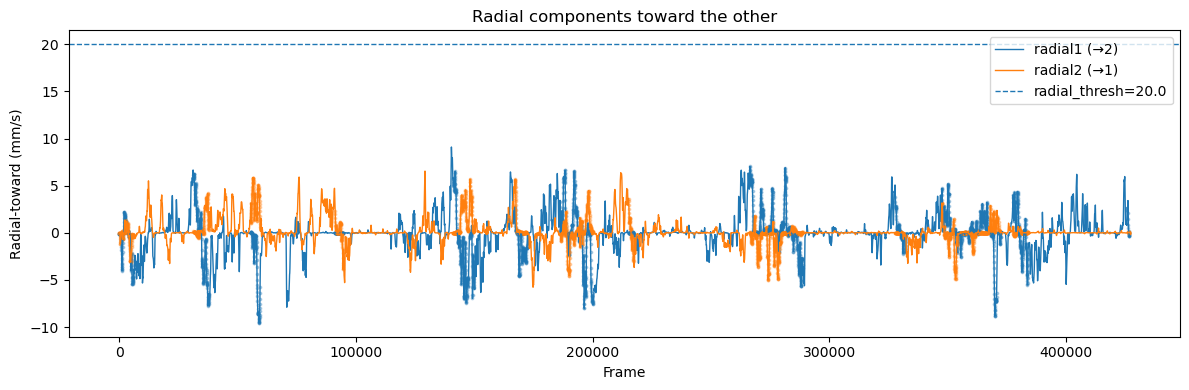

In [129]:
def plot_radials(frames, df, radial_thresh=20.0, dist_max=300.0):
    if "timestamp_ms_mini" in df.columns:
        t = df["timestamp_ms_mini"].to_numpy() / 1000.0
        xlab = "Time (s)"
    else:
        t = df.index.to_numpy()
        xlab = "Frame"

    r1 = frames["radial1"].to_numpy()
    r2 = frames["radial2"].to_numpy()
    d  = frames["dist_mm"].to_numpy()

    plt.figure(figsize=(12,4))
    plt.plot(t, r1, lw=1.0, label="radial1 (→2)")
    plt.plot(t, r2, lw=1.0, label="radial2 (→1)")
    plt.axhline(radial_thresh, ls="--", lw=1.0, label=f"radial_thresh={radial_thresh}")
    if dist_max is not None:
        plt.scatter(t[d<=dist_max], r1[d<=dist_max], s=3, alpha=0.3)
        plt.scatter(t[d<=dist_max], r2[d<=dist_max], s=3, alpha=0.3)
    plt.xlabel(xlab); plt.ylabel("Radial-toward (mm/s)")
    plt.title("Radial components toward the other")
    plt.legend(); plt.tight_layout(); plt.show()

plot_radials(frames, merged, radial_thresh=20.0, dist_max=300.0)


Suggested (radial) thresholds (mm/s): {50: 0.3635615983892557, 60: 0.7022114572265966, 70: 1.3459032445041377, 80: 2.293582513105207, 90: 3.853166780305512}
Suggested (speed) floors (mm/s): {50: 0.6970926723894353, 60: 1.3634142802009426, 70: 2.289240676762294, 80: 3.4085194561679044, 90: 4.992375745003763}


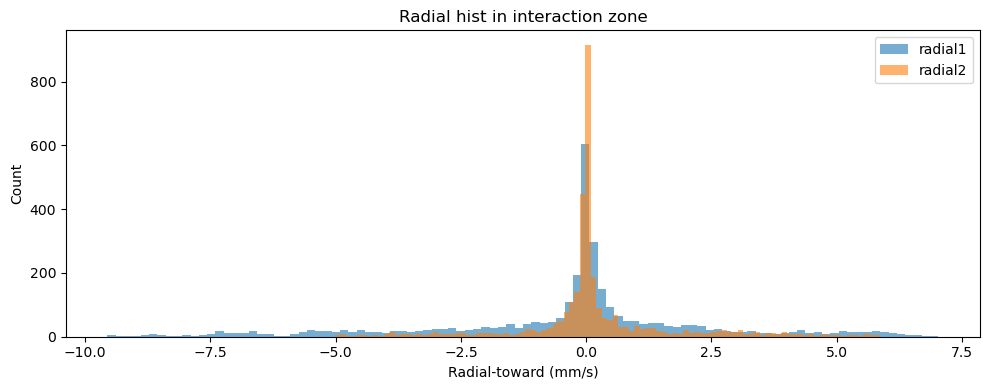

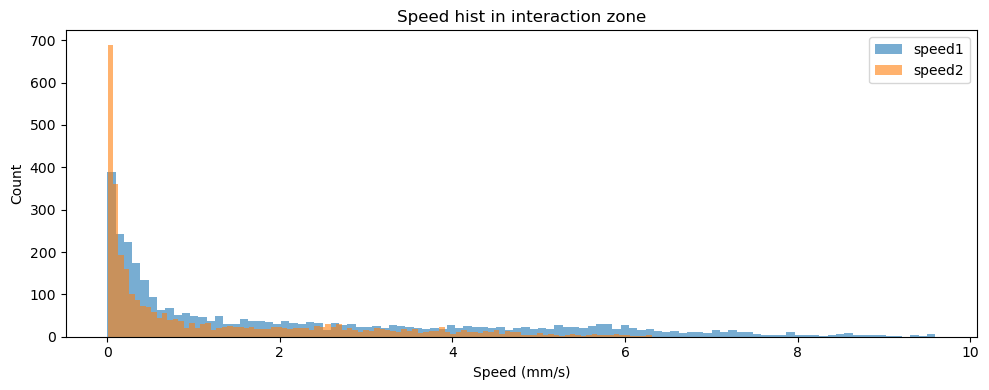

In [130]:
import numpy as np
import matplotlib.pyplot as plt

mask_zone = np.ones(len(frames), dtype=bool)
if res["frames"].attrs.get("velocity_units") == "mm/s":
    pass  # ok
# If you used dist_max in detect_approaches, keep the same band for hist
if "dist_mm" in frames:
    mask_zone &= (frames["dist_mm"].to_numpy() <= 300.0)

r1 = frames["radial1"].to_numpy()[mask_zone]
r2 = frames["radial2"].to_numpy()[mask_zone]
s1 = frames["speed1"].to_numpy()[mask_zone]
s2 = frames["speed2"].to_numpy()[mask_zone]

print("Suggested (radial) thresholds (mm/s):",
      {q: float(np.nanpercentile(np.concatenate([r1[r1>0], r2[r2>0]]), q)) for q in [50, 60, 70, 80, 90]})
print("Suggested (speed) floors (mm/s):",
      {q: float(np.nanpercentile(np.concatenate([s1, s2]), q)) for q in [50, 60, 70, 80, 90]})

plt.figure(figsize=(10,4)); plt.hist(r1, bins=100, alpha=0.6, label="radial1"); plt.hist(r2, bins=100, alpha=0.6, label="radial2")
plt.xlabel("Radial-toward (mm/s)"); plt.ylabel("Count"); plt.title("Radial hist in interaction zone"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4)); plt.hist(s1, bins=100, alpha=0.6, label="speed1"); plt.hist(s2, bins=100, alpha=0.6, label="speed2")
plt.xlabel("Speed (mm/s)"); plt.ylabel("Count"); plt.title("Speed hist in interaction zone"); plt.legend(); plt.tight_layout(); plt.show()


In [131]:
def _runs(mask):
    m = mask.astype(np.int8)
    edges = np.diff(np.pad(m, (1,1), constant_values=0))
    return np.flatnonzero(edges==1), np.flatnonzero(edges==-1)

def reflag(frames, radial_thresh=20.0, speed_min=5.0, dist_min=None, dist_max=300.0, min_samples=15):
    r1 = frames["radial1"].to_numpy()
    r2 = frames["radial2"].to_numpy()
    s1 = frames["speed1"].to_numpy()
    s2 = frames["speed2"].to_numpy()
    d  = frames["dist_mm"].to_numpy()
    in_band = np.ones_like(d, dtype=bool)
    if dist_min is not None: in_band &= (d >= dist_min)
    if dist_max is not None: in_band &= (d <= dist_max)
    a1 = (r1 >= radial_thresh) & (s1 >= speed_min) & in_band
    a2 = (r2 >= radial_thresh) & (s2 >= speed_min) & in_band

    # min duration
    def shrink(mask, k):
        if k<=1: return mask
        s,e=_runs(mask); keep=np.ones_like(mask, bool)
        for i in range(len(s)):
            if (e[i]-s[i])<k: keep[s[i]:e[i]]=False
        return mask & keep

    if min_samples>1:
        a1 = shrink(a1, min_samples)
        a2 = shrink(a2, min_samples)

    return a1, a2, (a1 & a2)

# try a grid quickly
for rad in [5,10,15,20,30]:
    for spd in [2,5,10]:
        a1,a2,mut = reflag(frames, radial_thresh=rad, speed_min=spd, dist_max=300.0, min_samples=10)
        print(f"radial≥{rad:>2}, speed≥{spd:>2}  ->  a1:{a1.sum():4d}  a2:{a2.sum():4d}  mutual:{mut.sum():4d}")


radial≥ 5, speed≥ 2  ->  a1: 106  a2:  26  mutual:   0
radial≥ 5, speed≥ 5  ->  a1: 106  a2:  26  mutual:   0
radial≥ 5, speed≥10  ->  a1:   0  a2:   0  mutual:   0
radial≥10, speed≥ 2  ->  a1:   0  a2:   0  mutual:   0
radial≥10, speed≥ 5  ->  a1:   0  a2:   0  mutual:   0
radial≥10, speed≥10  ->  a1:   0  a2:   0  mutual:   0
radial≥15, speed≥ 2  ->  a1:   0  a2:   0  mutual:   0
radial≥15, speed≥ 5  ->  a1:   0  a2:   0  mutual:   0
radial≥15, speed≥10  ->  a1:   0  a2:   0  mutual:   0
radial≥20, speed≥ 2  ->  a1:   0  a2:   0  mutual:   0
radial≥20, speed≥ 5  ->  a1:   0  a2:   0  mutual:   0
radial≥20, speed≥10  ->  a1:   0  a2:   0  mutual:   0
radial≥30, speed≥ 2  ->  a1:   0  a2:   0  mutual:   0
radial≥30, speed≥ 5  ->  a1:   0  a2:   0  mutual:   0
radial≥30, speed≥10  ->  a1:   0  a2:   0  mutual:   0


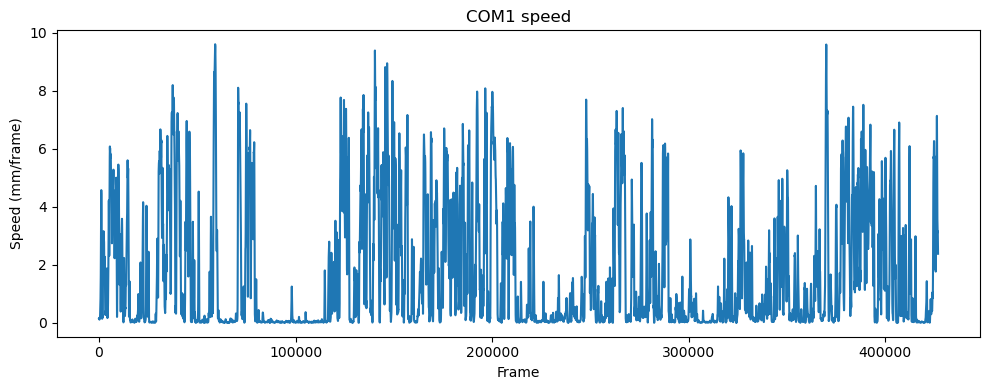

In [132]:
import matplotlib.pyplot as plt

# assuming you've already done:
# m1 = compute_motion_direction(merged, prefix="com1", time_col="timestamp_ms_mini", pos_smooth=5, vel_smooth=5)

# time axis
if "timestamp_ms_mini" in merged.columns:
    t = merged["timestamp_ms_mini"].to_numpy() / 1000.0
    xlab = "Time (s)"
else:
    t = merged.index.to_numpy()
    xlab = "Frame"

plt.figure(figsize=(10, 4))
plt.plot(t, m1["com1_speed"].to_numpy())
plt.xlabel(xlab)
plt.ylabel("Speed (mm/s)" if xlab=="Time (s)" else "Speed (mm/frame)")
plt.title("COM1 speed")
plt.tight_layout()
plt.show()


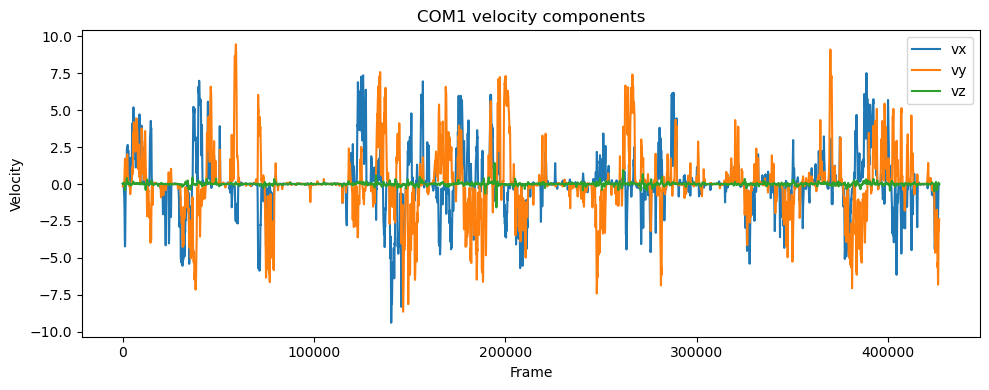

In [133]:
plt.figure(figsize=(10, 4))
plt.plot(t, m1["com1_vx"].to_numpy(), label="vx")
plt.plot(t, m1["com1_vy"].to_numpy(), label="vy")
plt.plot(t, m1["com1_vz"].to_numpy(), label="vz")
plt.xlabel(xlab); plt.ylabel("Velocity")
plt.title("COM1 velocity components")
plt.legend()
plt.tight_layout(); plt.show()


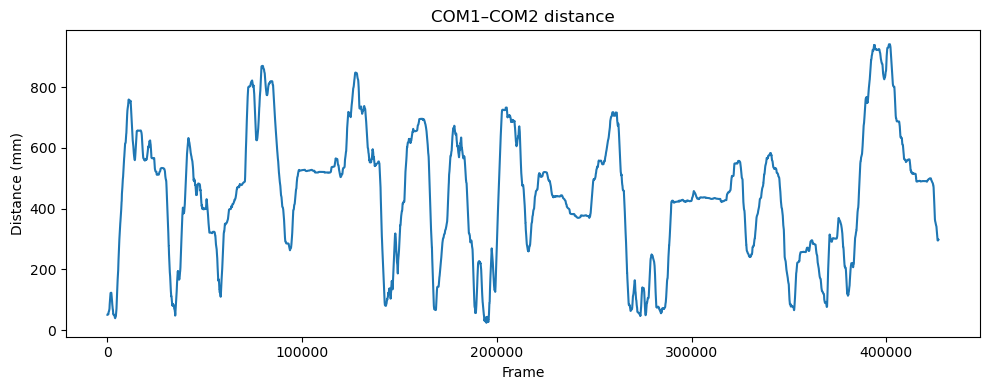

In [134]:
# simplest distance trace
dist = compute_com_distance(merged, p1="com1", p2="com2", smooth_window=1)

if "timestamp_ms_mini" in merged.columns:
    t = merged["timestamp_ms_mini"].to_numpy() / 1000.0
    xlab = "Time (s)"
else:
    t = merged.index.to_numpy()
    xlab = "Frame"

plt.figure(figsize=(10, 4))
plt.plot(t, dist.to_numpy())
plt.xlabel(xlab)
plt.ylabel("Distance (mm)")
plt.title("COM1–COM2 distance")
plt.tight_layout()
plt.show()


In [135]:
dist[dist <= 100.0]

timestamp_ms_mini
-5         50.677300
 35        50.504660
 64        50.560605
 97        51.037087
 130       51.239932
             ...    
 369542    77.964388
 369574    78.284982
 369610    83.890038
 369643    90.012795
 369676    96.639576
Name: dist_mm, Length: 886, dtype: float64

In [136]:
# res

In [137]:
# m1

In [29]:
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple

def _boolean_runs(mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    if mask.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    m = mask.astype(np.int8)
    edges = np.diff(np.pad(m, (1, 1), constant_values=0))
    starts = np.flatnonzero(edges == 1)
    ends   = np.flatnonzero(edges == -1)
    return starts, ends

def find_approach_success(
    frames: pd.DataFrame,
    contact_mm: float = 50.0,     # "touch" threshold
    dD_dt_thresh: float = 0.0,    # <= 0 means distance not increasing
    min_len: int = 10,            # min frames from start of closing to contact
    min_drop_mm: float = 10.0     # require at least this much net distance drop
) -> Tuple[np.ndarray, List[Dict]]:
    """
    Returns:
      mask  : boolean array marking frames that belong to approach_success events
      events: list of dicts with indices and metrics for each event

    Uses only frames['dist_mm'] and frames['dD_dt'].
    """
    dist = frames["dist_mm"].to_numpy()
    closing = frames["dD_dt"].to_numpy() <= float(dD_dt_thresh)
    contact = dist <= float(contact_mm)

    s_close, e_close = _boolean_runs(closing)

    mask = np.zeros(len(frames), dtype=bool)
    events: List[Dict] = []

    for s, e in zip(s_close, e_close):
        # first contact inside this closing run (if any)
        within = np.flatnonzero(contact[s:e])
        if within.size == 0:
            continue
        k = s + int(within[0])  # first contact index

        # length and net drop checks
        length_ok = (k - s + 1) >= int(min_len)
        drop_ok   = (dist[s] - dist[k]) >= float(min_drop_mm)
        if not (length_ok and drop_ok):
            continue

        mask[s:k+1] = True
        events.append({
            "start_idx": int(s),
            "end_idx_exclusive": int(k + 1),
            "contact_idx": int(k),
            "start_dist_mm": float(dist[s]),
            "end_dist_mm": float(dist[k]),
            "drop_mm": float(dist[s] - dist[k]),
            "duration_frames": int(k - s + 1),
        })

    return mask, events


In [142]:
res

{'frames':                       dist_mm     dD_dt   radial1   radial2    speed1  \
 timestamp_ms_mini                                                       
 -5                  50.580713  0.113544 -0.079223 -0.037451  0.154367   
  35                 50.694257  0.111260 -0.088469 -0.045433  0.162126   
  64                 50.803232  0.126061 -0.100860 -0.051929  0.167439   
  97                 50.946379  0.185027 -0.104587 -0.061919  0.159762   
  130                51.173287  0.228116 -0.103649 -0.064261  0.147180   
 ...                       ...       ...       ...       ...       ...   
  426643            296.175032  0.308035 -0.285902 -0.000748  3.102922   
  426677            296.519910  0.373207 -0.310426 -0.001421  2.940469   
  426710            296.921445  0.330286 -0.323278 -0.001564  2.769820   
  426743            297.180483  0.262535 -0.328146 -0.001626  2.665520   
  426776            297.446515  0.266032 -0.308292 -0.001498  2.378416   
 
                      spee

In [36]:
# 0) Run your detector first
mask, events = find_approach_success(
    res["frames"],
    contact_mm=50.0,
    dD_dt_thresh=0.0,
    min_len=10,
    min_drop_mm=20.0
)

frames = res["frames"]

print(f"#approach_success events: {len(events)}")

# 1) Pick available alignment / time columns (kept by detect_approaches if present)
frame_col = None
for c in ("camera_frame_sixcam", "mapped_sixcam_frame_indices"):
    if c in frames.columns:
        frame_col = c
        break

mini_ms_col = "timestamp_ms_mini" if "timestamp_ms_mini" in frames.columns else None

# 2) Flatten all approach_success frames into simple lists you can feed elsewhere
incident_index   = frames.index[mask].tolist()  # generic index (could be ints or timestamps)
incident_sixcam  = frames.loc[mask, frame_col].astype(int).tolist() if frame_col else incident_index
incident_mini_ms = frames.loc[mask, mini_ms_col].astype(float).tolist() if mini_ms_col else None

# 3) Keep a column for quick plotting/QA
frames2 = frames.copy()
frames2["approach_success"] = mask




#approach_success events: 4


In [37]:
from utlis.vis_valid_utlis.sdannce_vis import cfg, visualize_frames
C = cfg(base_path="/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30", cammm=1, 
        enable_zoom=True, zoom_margin=450) #animal="mouse20", #write_pngs=True


# # pick the alignment column once
# frame_col = "camera_frame_sixcam" if "camera_frame_sixcam" in frames.columns \
#     else ("mapped_sixcam_frame_indices" if "mapped_sixcam_frame_indices" in frames.columns else None)

# # visualize the FIRST event using six-cam frame numbers
# if events:
#     s = events[0]["start_idx"]
#     e = events[0]["end_idx_exclusive"]
#     if frame_col:
#         incident_six_cam = frames.loc[s:e-1, frame_col].astype(int).tolist()
#         visualize_frames(incident_six_cam, config=C, out_name="incident_01")
#     else:
#         # fallback: use index range if six-cam column not available
#         incident = list(range(s, e))
#         visualize_frames(incident, config=C, out_name="incident_01")


In [156]:
incident_all_six_cam = frames.loc[mask, frame_col].astype(int).tolist() if frame_col else frames.index[mask].tolist()


100%|██████████| 254/254 [00:27<00:00,  9.38it/s]


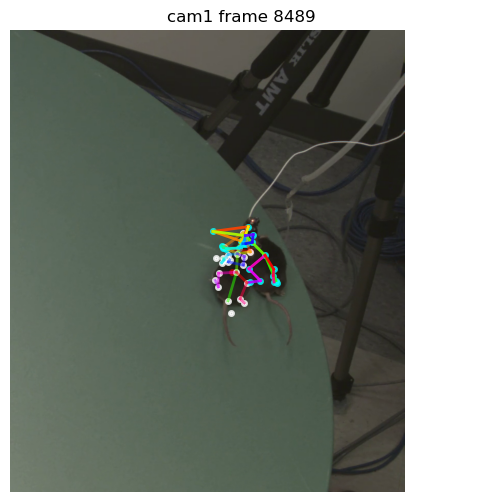

In [157]:
visualize_frames(incident_all_six_cam, config=C, out_name="all_incidents")

#approach_success events: 4


 16%|█▌        | 40/254 [00:04<00:23,  9.02it/s]


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1800x1800', '-pix_fmt', 'rgba', '-framerate', '20', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-metadata', 'title=combined_visualization', '-metadata', 'artist=Matplotlib', '-y', '/data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30/SDANNCE/predict00/vis/vis_all_incidents.mp4']' returned non-zero exit status 255.

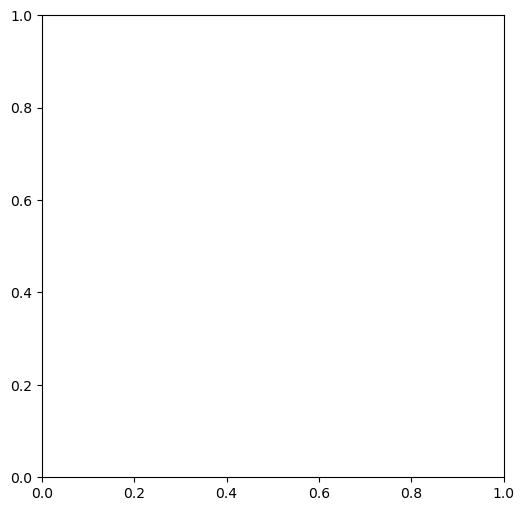

In [160]:
# 0) Run your detector first
mask, events = find_approach_success(
    res["frames"],
    contact_mm=50.0,
    dD_dt_thresh=0.0,
    min_len=10,
    min_drop_mm=10.0
)

frames = res["frames"]

print(f"#approach_success events: {len(events)}")

incident_all_six_cam = frames.loc[mask, frame_col].astype(int).tolist() if frame_col else frames.index[mask].tolist()

visualize_frames(incident_all_six_cam, config=C, out_name="all_incidents")

In [161]:
def pick_alignment_cols(frames):
    frame_col = None
    for c in ("camera_frame_sixcam", "mapped_sixcam_frame_indices"):
        if c in frames.columns:
            frame_col = c
            break
    mini_ms_col = "timestamp_ms_mini" if "timestamp_ms_mini" in frames.columns else None
    return frame_col, mini_ms_col


def extract_incidents(frames, events, frame_col=None, mini_ms_col=None):
    """
    Turns events into simple per-event lists you can feed to other funcs.
    Returns a list of dicts:
      {"start_idx", "end_idx_exclusive", "index", "sixcam", "mini_ms"}
    Missing cols are omitted.
    """
    out = []
    for ev in events:
        s, e = ev["start_idx"], ev["end_idx_exclusive"]
        sl = slice(s, e)
        item = {
            "start_idx": s,
            "end_idx_exclusive": e,
            "index": frames.index[sl].tolist()
        }
        if frame_col:
            item["sixcam"] = frames.iloc[sl][frame_col].astype(int).tolist()
        if mini_ms_col:
            item["mini_ms"] = frames.iloc[sl][mini_ms_col].astype(float).tolist()
        out.append(item)
    return out


import numpy as np
import matplotlib.pyplot as plt

def plot_dist_with_events(frames, mask, events, contact_mm=50.0, title=None):
    dist = frames["dist_mm"].to_numpy()
    x = frames.index

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(x, dist, lw=1, label="dist_mm")
    ax.scatter(x[mask], dist[mask], s=8, label="approach_success", zorder=3)
    ax.axhline(contact_mm, ls="--", lw=1, label=f"contact={contact_mm} mm")

    if events:
        contact_idx = np.array([ev["contact_idx"] for ev in events], dtype=int)
        ax.scatter(x[contact_idx], dist[contact_idx], marker="x", s=36, zorder=4, label="first contact")

        # light spans per event (fast; number of events is small)
        for ev in events:
            s, e = ev["start_idx"], ev["end_idx_exclusive"]
            ax.axvspan(x[s], x[e-1], alpha=0.15)

    ax.set_ylabel("distance (mm)")
    ax.set_xlabel("frame")  # or "time" if your index is time-like
    ax.set_title(title or f"Approach-success events (n={len(events)})")
    ax.legend(loc="best")
    plt.tight_layout()
    return fig, ax


def plot_single_event(frames, ev, contact_mm=50.0):
    s, e = ev["start_idx"], ev["end_idx_exclusive"]
    sl = slice(s, e)
    x = frames.index[sl]
    dist = frames["dist_mm"].iloc[sl]

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(x, dist, lw=1.2)
    ax.axhline(contact_mm, ls="--", lw=1)
    # mark first contact if ev has it
    if "contact_idx" in ev:
        cx = frames.index[ev["contact_idx"]]
        ax.scatter([cx], [frames["dist_mm"].iloc[ev["contact_idx"]]], marker="x", s=36, zorder=4)
    ax.set_ylabel("distance (mm)")
    ax.set_xlabel("frame")
    ax.set_title(f"Event [{s}:{e})  drop={ev.get('drop_mm', np.nan):.1f}mm")
    plt.tight_layout()
    return fig, ax


#approach_success events: 4
0 {'start_idx': 57, 'end_idx_exclusive': 105, 'contact_idx': 104, 'start_dist_mm': 123.24438319872635, 'end_dist_mm': 49.64906601830635, 'drop_mm': 73.59531718042001, 'duration_frames': 48}
1 {'start_idx': 5680, 'end_idx_exclusive': 5754, 'contact_idx': 5753, 'start_dist_mm': 227.01874905557938, 'end_dist_mm': 48.84090820142293, 'drop_mm': 178.17784085415644, 'duration_frames': 74}
2 {'start_idx': 8058, 'end_idx_exclusive': 8140, 'contact_idx': 8139, 'start_dist_mm': 163.66949513516516, 'end_dist_mm': 49.73480333720715, 'drop_mm': 113.93469179795801, 'duration_frames': 82}


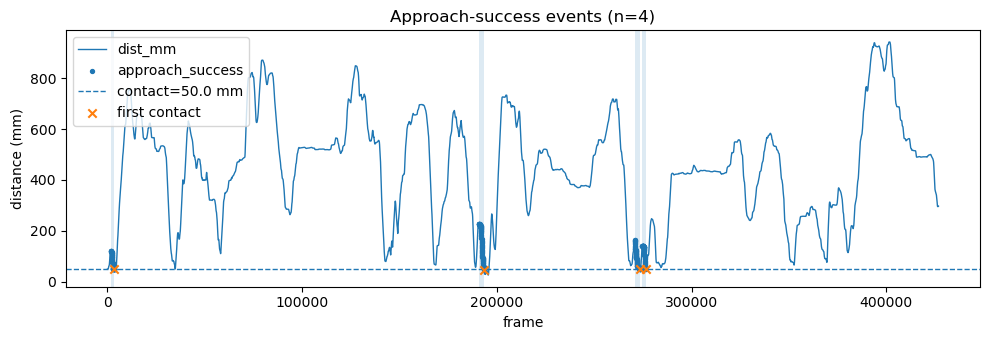

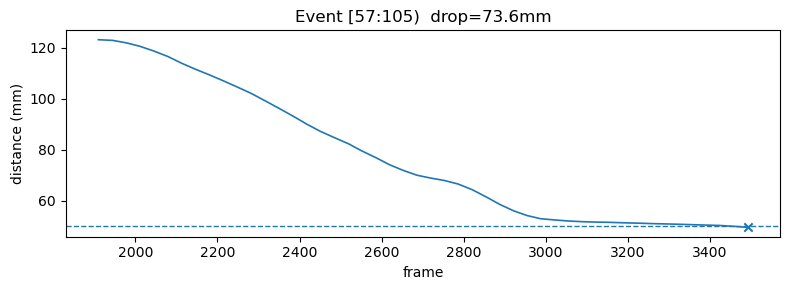

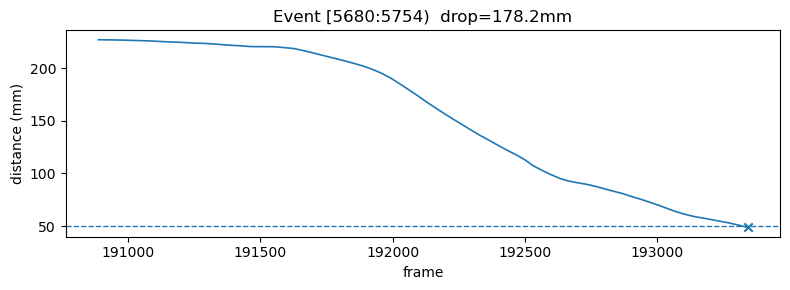

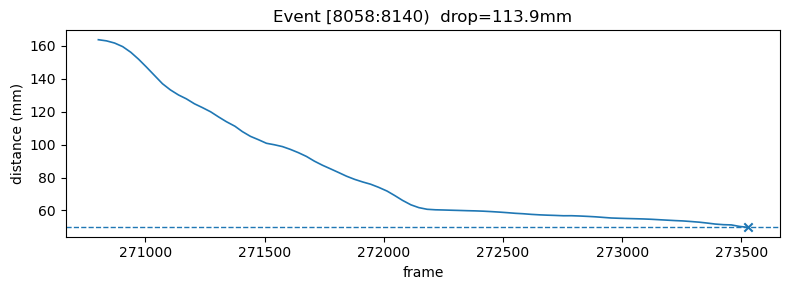

In [162]:
# run detectors
mask, events = find_approach_success(
    res["frames"],
    contact_mm=50.0,
    dD_dt_thresh=0.0,
    min_len=10,
    min_drop_mm=10.0
)
frames = res["frames"]

# pick columns & extract per-event lists
frame_col, mini_ms_col = pick_alignment_cols(frames)
incidents = extract_incidents(frames, events, frame_col, mini_ms_col)

print(f"#approach_success events: {len(events)}")
# quick peek
for k, ev in enumerate(events[:3]):
    print(k, ev)

# global plot
plot_dist_with_events(frames, mask, events, contact_mm=50.0)

# per-event quick QA plots (limit to first N to keep it light)
N = min(3, len(events))
for i in range(N):
    plot_single_event(frames, events[i], contact_mm=50.0)

# when ready later for video viz, you have a clean per-event sixcam list:
# visualize_frames(incidents[i]["sixcam"], config=C, out_name=f"incident_{i:02d}")


In [149]:
events

[{'start_idx': 57,
  'end_idx_exclusive': 105,
  'contact_idx': 104,
  'start_dist_mm': 123.24438319872635,
  'end_dist_mm': 49.64906601830635,
  'drop_mm': 73.59531718042001,
  'duration_frames': 48},
 {'start_idx': 5680,
  'end_idx_exclusive': 5754,
  'contact_idx': 5753,
  'start_dist_mm': 227.01874905557938,
  'end_dist_mm': 48.84090820142293,
  'drop_mm': 178.17784085415644,
  'duration_frames': 74},
 {'start_idx': 8058,
  'end_idx_exclusive': 8140,
  'contact_idx': 8139,
  'start_dist_mm': 163.66949513516516,
  'end_dist_mm': 49.73480333720715,
  'drop_mm': 113.93469179795801,
  'duration_frames': 82},
 {'start_idx': 8174,
  'end_idx_exclusive': 8224,
  'contact_idx': 8223,
  'start_dist_mm': 140.1295736764331,
  'end_dist_mm': 49.738201477758125,
  'drop_mm': 90.39137219867497,
  'duration_frames': 50}]

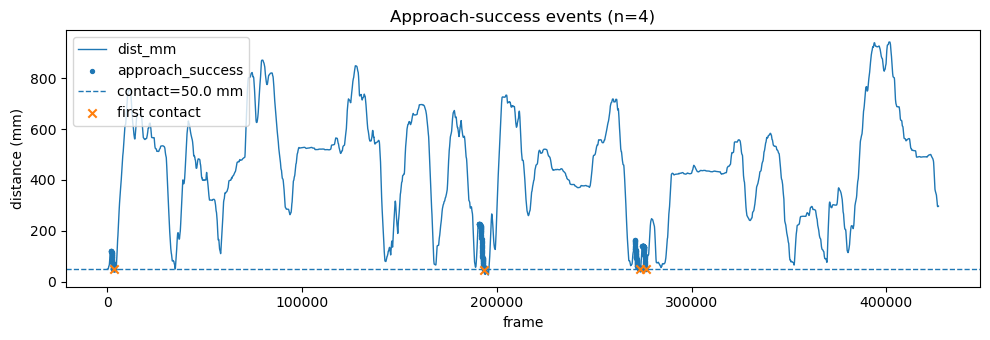

In [158]:
import numpy as np
import matplotlib.pyplot as plt

# 1) 先从 detect_approaches 的结果里取出 frames
frames = res["frames"]                    # 包含 dist_mm, dD_dt 等
dist = frames["dist_mm"].to_numpy()
x = frames.index                          # 横轴用 df 的索引（帧或对齐后的时间索引）

# 2) 发现 approach_success 事件（用你刚加的函数）
mask, events = find_approach_success(
    frames,
    contact_mm=50.0,      # 触碰/接触阈值（按你的 COM 定义调）
    dD_dt_thresh=0.0,     # <=0 表示距离不增加；更严格可设为负数如 -5
    min_len=10,           # 至少持续 10 帧
    min_drop_mm=20.0      # 距离至少下降 20 mm
)

# 3) 画图：距离曲线 + 事件高亮（不需要循环，直接用散点叠加）
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(x, dist, lw=1, label="dist_mm")

# 高亮 approach_success 区间的点
ax.scatter(x[mask], dist[mask], s=8, label="approach_success", zorder=3)

# 触碰阈值线
contact_mm = 50.0
ax.axhline(contact_mm, ls="--", lw=1, label=f"contact={contact_mm} mm")

# 标出每个事件的“首次接触”帧（仅做标记，事件数量通常不多，这里轻量循环）
if events:
    contact_idx = np.array([ev["contact_idx"] for ev in events], dtype=int)
    ax.scatter(x[contact_idx], dist[contact_idx], marker="x", s=36, zorder=4, label="first contact")

ax.set_ylabel("distance (mm)")
ax.set_xlabel("frame")    # 如果你的 index 是时间戳，可以改成 "time"
ax.set_title(f"Approach-success events (n={len(events)})")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [159]:
F = res["frames"]

# How many frames would count as "pairwise closing"?
closing = F["dD_dt"] <= 0.0
print("closing frames:", int(closing.sum()))

# Compare with per-animal directional flags you used (example thresholds)
a1 = (F["radial1"] >= 5) & (F["speed1"] >= 2) & (F["dist_mm"] <= 300)
a2 = (F["radial2"] >= 5) & (F["speed2"] >= 2) & (F["dist_mm"] <= 300)
print("a1 frames:", int(a1.sum()), "a2 frames:", int(a2.sum()), "overlap:", int((a1 & a2).sum()))

# Identity check: radial1 + radial2 ≈ -dD_dt (sanity of kinematics)
err = (F["radial1"] + F["radial2"] + F["dD_dt"]).abs()
print("median |radial1+radial2 + dD_dt| =", float(err.median()))


closing frames: 6282
a1 frames: 136 a2 frames: 33 overlap: 0
median |radial1+radial2 + dD_dt| = 0.05435335311075665
